# merge industry coordinates with rule

In [1]:
import numpy as np
import pandas as pd
import ast
import networkx as nx
from tqdm import tqdm

## parse industry rules

In [2]:
rule_df = pd.read_csv(r'C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\raw\industry_rule.csv')
rule_df.columns

Index(['fileName', 'rule'], dtype='object')

In [3]:
rule_df['rule'] = rule_df['rule'].apply(lambda x: ast.literal_eval(x))

In [4]:
rule_df['input_material'] = rule_df['rule'].apply(lambda x: x['stocks'])
rule_df['input_proportion'] = rule_df['rule'].apply(lambda x: x['rule']['input'])

rule_df['output_material'] = rule_df['rule'].apply(lambda x: list(x['rule']['output'].keys()))
rule_df['output_proportion'] = rule_df['rule'].apply(lambda x: list(x['rule']['output'].values()))

rule_df['capacity'] = rule_df['rule'].apply(lambda x: x['rule']['capacity'])

In [5]:
coord_df = pd.read_csv(r'C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\raw\industry_coords.csv')
coord_df.drop(columns=['Unnamed: 6'], inplace=True)
coord_df.columns

Index(['fileName', 'id', 'name', 'x', 'y', 'z'], dtype='object')

In [6]:
coord_df['construction'] = coord_df['fileName'].apply(lambda x: x.split(r'/')[0])
coord_df['confile'] = coord_df['fileName'].apply(lambda x: x.split(r'/')[-1])
coord_df = coord_df.loc[coord_df['construction']=='industry']


In [7]:
df = pd.merge(left=coord_df, right=rule_df,
              left_on='confile', right_on='fileName')
df.columns

Index(['fileName_x', 'id', 'name', 'x', 'y', 'z', 'construction', 'confile',
       'fileName_y', 'rule', 'input_material', 'input_proportion',
       'output_material', 'output_proportion', 'capacity'],
      dtype='object')

In [10]:
df = df[[ 'id', 'name', 'x', 'y', 'z', 'confile', 'input_material', 'input_proportion',
       'output_material', 'output_proportion', 'capacity']]

In [11]:
df['rule'] = df.apply(lambda x: {f'{key}': x[value] for value, key in enumerate(df.columns) if value!=0},
                      axis=1)

df = df[['id', 'rule']]

C:\Users\prade\AppData\Local\Temp\ipykernel_27116\3354097373.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['rule'] = df.apply(lambda x: {f'{key}': x[value] for value, key in enumerate(df.columns) if value!=0},


## create graph

In [12]:
G = nx.DiGraph() # directed graph

In [23]:
for i in tqdm(range(len(df))):
    G.add_node(df['id'].iloc[i].item(), **df['rule'].iloc[i])

100%|██████████| 66/66 [00:00<00:00, 45680.54it/s]


In [17]:
df['rule']

0     {'name': ' Ranchi Iron ore mine', 'x': -1588.0...
1     {'name': ' Bangkok Chemical plant', 'x': -2140...
2     {'name': ' Bangkok Oil refinery', 'x': -4344.0...
3     {'name': ' Hangzhou Paper mill', 'x': -6640.0,...
4     {'name': ' Bangkok Construction materials plan...
                            ...                        
61    {'name': ' Yerevan Silver ore mine', 'x': 2308...
62    {'name': ' Busan Oil well', 'x': 3380.0, 'y': ...
63    {'name': ' Jakarta Goods factory', 'x': 6172.0...
64    {'name': ' Busan Construction materials plant'...
65    {'name': ' Busan Saw mill', 'x': 2824.0, 'y': ...
Name: rule, Length: 66, dtype: object

In [14]:
df['id']

0      7838
1      6453
2     16226
3      9551
4      7488
      ...  
61    15334
62    18028
63     7098
64     7719
65    13915
Name: id, Length: 66, dtype: int64

In [30]:
G.nodes[7850]

{'name': ' Bangkok Goods factory',
 'x': -3492.0,
 'y': -2992.0,
 'z': 4.4,
 'confile': 'advanced_goods_factory.con',
 'input_material': ['PLASTIC', 'PLANKS', 'PAPER', 'SILVER'],
 'input_proportion': [[1, 1, 0, 0], [1, 0, 1, 0], [1, 0, 0, 1]],
 'output_material': ['GOODS'],
 'output_proportion': [1],
 'capacity': 100}

In [29]:
nodes = list(G.nodes())


## adding directed edges; with industries supply and demand

In [31]:
for supply_node in tqdm(nodes):
    for demand_node in nodes:
        for supply in G.nodes[supply_node]['output_material']:
            if supply in G.nodes[demand_node]['input_material']:
                G.add_edge(supply_node, demand_node)
                break


100%|██████████| 66/66 [00:00<00:00, 23233.24it/s]


In [32]:
G.number_of_edges()

163

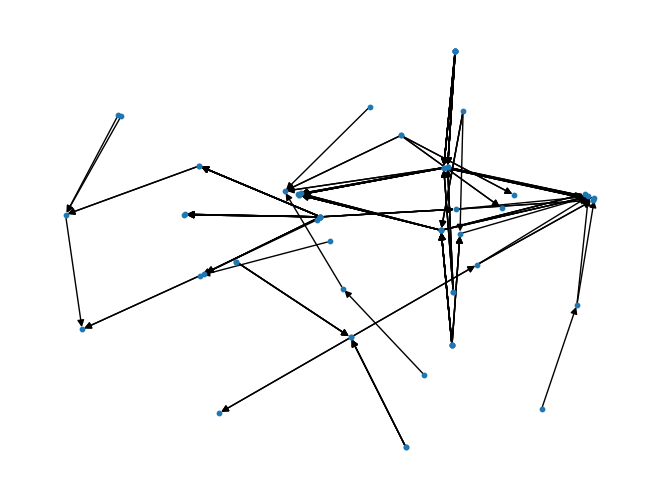

In [39]:
nx.draw_kamada_kawai(G, node_size=10)